# Chapter4:

## ***Monte Carlo:*** Randomness, Walks, and Decays

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

### 4.1: Introduction

many computer cyclesareused forMonte
Carlo calculations that at their very core include elements of *chance*. These are
calculations in which random-like numbers generated by the computer are used
to simulate naturally random processes, such as thermal motion or radioactive decay, or to solve equations on the average.

### 4.2: Random Sequences (theory)
#### Definitions
**I. Random Sequence:** we define sequence $ r_{1}, r_{2}, ... $ as *random* if there are no correlations among the numbers. Yet being random does not mean that all the numbers in the sequence are equally likely to occur.

**II. Uniform Sequence:**  If all the numbers in a sequence are equally likely to occur, then the sequence is called *uniform*, which doesnot say anything about being random.

To illustrate, 1,2,3,4,... is uniform but probably not random.

note: it is possible for some sequence of numbers to be random but have "very short-range correlations" among themselves. like: 
\begin{align}
    r_{1},(1-r_{1}),r_{2},(1-r_{2}),r_{3},(1-r_{3}),...
    \tag{4.1}
\end{align}

The chance of a number occuring is described by distribution (probability) function $P(r)$ and $P(r)$ is probability of finding $r$ in interval $[r+dr]$ . In uniform distributions, $P(r) =$ a constant. The standard random-number generator on computers generates uniform distributions between 0  and 1.

By their nature, computers are deterministic and so cannot create a random sequence. That means computed random number sequences must contain correlations and are not truly random. So if we know a computed random number $r_{m}$ and its preceding elements, then it is always possible to figure out $r_{m+1}$ . For this reason, computers are said to generate *pseudorandom numbers* , but we are lazy and call it random!

#### 4.2.1 Random-Number Generation (Algorithm)

The *linear congruent* or *power residue* method is the common way of generating a pseudorandom sequence of numbers $r_{i}$ over the interval $[0,M-1]$.

To obtain the next random number $r_{i+1}$, you multiply the present random number $r_{i}$  by a constant $a$, add another constant $c$, take the *modulus* by M and then keep juts the fractional part:

\begin{align}
r_{i+1} &\overset{\mathrm{def}}{=} (a r_i + c) \bmod M \tag{4.2} \\
&= \mathrm{remainder}\!\left( \frac{a r_i + c}{M} \right). \tag{4.3}
\end{align}

The value for $r_{1}$ is called *seed* and is supplied by the user, and *mod* is function for *remaindering* (% in python).

example:


In [2]:
a = 4; c = 1; M = 9; r1 = 3

# r1 = 3

r2 = (4*r1 + 1) % 9

print(r2)

r3 = (4*r2 + 1) % 9

print(r3)

r4 = (4*r3 + 1) % 9

print(r4)

4
8
6


In [3]:
# more automated code
a = 4 ; c = 1 ; M = 9 ; r1 = 3 # for modulus M, our interval will be [0, M-1], so here [0, 8]

randomlist = [r1]

counter = 10 # we would like to generate 10 random number

for i in range(0, counter):
    r = (4 * randomlist[i] + 1) % M
    randomlist.append(r)

print(randomlist)

[3, 4, 8, 6, 7, 2, 0, 1, 5, 3, 4]


note1: once again, remind that for a chosen *M*, you will have an interval of [0,*M*-1] for your random number, and, for chosen *M*, your random sequence will have length of M. Although with bad choice of numbers, sequence could repeat much earlier!

note2: When modulus is a power of 2, you can take this process as a bit-shift operation which remains the least significant part of the input number.
example:

In [4]:
result = int('110010101110100101000100101', 2) # storing our number as binary

M = 256  # 2**8

rem = result % M

print(format(rem, '08b'))


00100101


In code box [2], we got a random sequence (as list) of length *M* = 9 which after that the sequece will just repeat itself (notice the 3 and 4 at the end of the sequence).

If we want to get random numbers in range [0,1], we devide our random numbers by *M* = 9 :

In [5]:
randomlist_01 = []
for i in range(0,11):
    randomlist_01.append((randomlist[i] / 9))
print(randomlist_01)

[0.3333333333333333, 0.4444444444444444, 0.8888888888888888, 0.6666666666666666, 0.7777777777777778, 0.2222222222222222, 0.0, 0.1111111111111111, 0.5555555555555556, 0.3333333333333333, 0.4444444444444444]


If random numbers in range[*A*,*B*] are needed, we should scale:

\begin{aligned}
    x_{i} = A + (B-A)r_{i} \quad , \qquad 0 \le r_{i} \le 1 \quad , \qquad \Rightarrow \qquad A \le x_{i} \le B \quad .
    \tag{4.4}
\end{aligned}

In [6]:
# if we would like randoms in interval of [4,18]
randomlist418 = []
for i in range(0,9):
    randomlist418.append(int(4 + (18 - 4)*randomlist_01[i]))

print(randomlist418)

[8, 10, 16, 13, 14, 7, 4, 5, 11]


***Before using a rabdom-number generator in your code, you should check its range and that it produces numbers that "look" random.***

Although its not a mathematical proof, but you should always make graphical display of your random numbers. It is easier to recognize patterns in graphic rather than numbers.

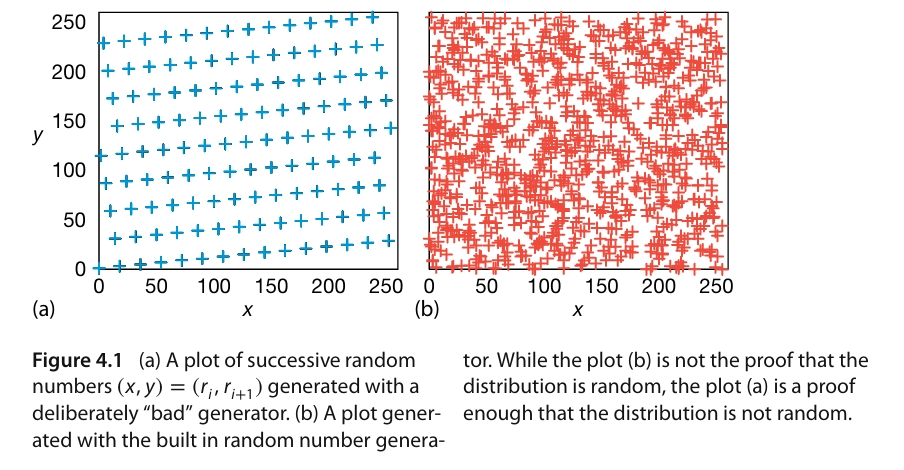


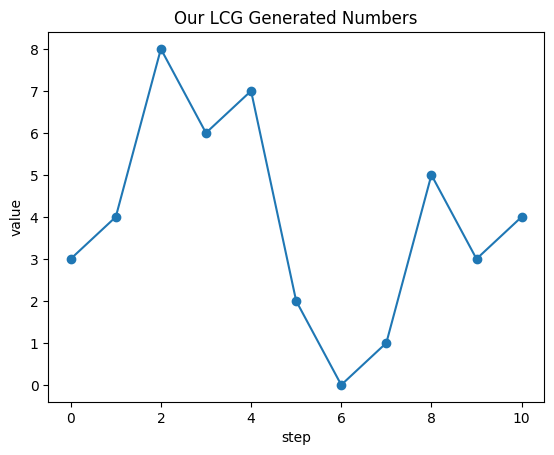

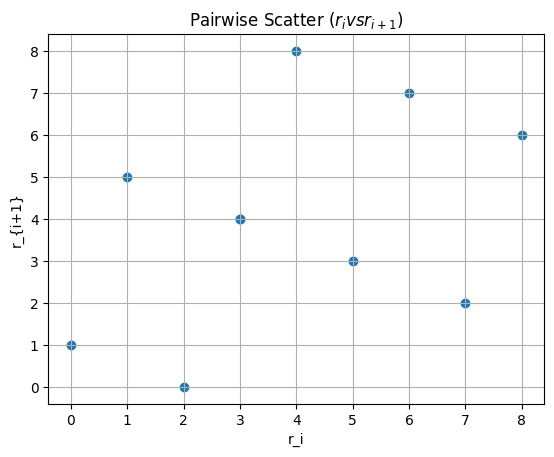

In [7]:
import matplotlib.pyplot as plt

plt.plot(randomlist, marker='o')
plt.title("Our LCG Generated Numbers")
plt.xlabel("step")
plt.ylabel("value")
plt.show()

plt.scatter(randomlist[:-1], randomlist[1:])
plt.title("Pairwise Scatter ($r_i vs r_{i+1})$")
plt.xlabel("r_i")
plt.ylabel("r_{i+1}")
plt.grid(True)
plt.show()

The LCG method (4.2) becomes completely correlated if a particular integer shows up for a second time (that means the whole cycle started to repeat). In order to obtain longer sequence, *a* and *M* should be large numbers but not so large that $ar_{i-1}$ overflows (the multiplication must fit in machine bits (32/48/64 bits of computers)). On a computer using 48-bit integer arithmetic, the built-in random-number generator may use *M* values as large as $2^{48}$ . A 32-bit computer may use *M* = $2^{32}$ . For computers using this many random numbers, **we need to reseed and start sequence again with a different initial values.**

Your computer probably has random-number generators that are better than the one you will compute with the LCG method. In Python, we use `random` library for generating random numbers.

To initialize a random sequence, you need to plant a seed in it. In python, the command `random.seed(None)` seeds the random sequence generator. `None` or empty argument, seeds the generator with the system time.

#### 4.2.2 Implementation: Random Sequences

For scientific work, it is recommended using an industrial-strength random-number generator. To see why, we assess how bad a careless application of the LCG method can be.

1. Write a simple program to generate random numbers using LCG method (4.2).
2. For educational & teaching purposes, try the unwise choice of initial conditions: (*a, c, M, $r_{1}$*) = (57, 1, 256, 10). Determine the *period* which is how many numbers are generated before the sequence repeats itself.
3. Take the sequence of random numbers and look for correlations by observing clustering on a plot of successive pairs $(x_{i}, y_{i}) = (r_{2i-1}, r_{2i})$. Do NOT connect the points with line. You may ovserve correlations, which means you should not use this sequence for serious work.
4. Make your own version of Figure 4.2 by plotting $r_{i}$ vs $i$.
5. Test the built-in random-number generator on your computer (python random library) for correlations by plotting the same pairs as above (This should be good for serious work.)
6. Test the LCG method again with reasonable constants as mentioned above (you can also ask AI for that). (This too, should be good for serious work.)


In [8]:
a = 57 ; c = 1 ; m = 2**8 ; r1 = 10
# as m = 256, so our interval will be [0,255], so we can have 256 (including zero and r1)
# random number maximum before the sequence repeat itself.
randseq = [r1]
for j in range (0, 255):
    randseq.append(((((a * randseq[j])) + c) % m))
print(randseq)

[10, 59, 36, 5, 30, 175, 248, 57, 178, 163, 76, 237, 198, 23, 32, 33, 90, 11, 116, 213, 110, 127, 72, 9, 2, 115, 156, 189, 22, 231, 112, 241, 170, 219, 196, 165, 190, 79, 152, 217, 82, 67, 236, 141, 102, 183, 192, 193, 250, 171, 20, 117, 14, 31, 232, 169, 162, 19, 60, 93, 182, 135, 16, 145, 74, 123, 100, 69, 94, 239, 56, 121, 242, 227, 140, 45, 6, 87, 96, 97, 154, 75, 180, 21, 174, 191, 136, 73, 66, 179, 220, 253, 86, 39, 176, 49, 234, 27, 4, 229, 254, 143, 216, 25, 146, 131, 44, 205, 166, 247, 0, 1, 58, 235, 84, 181, 78, 95, 40, 233, 226, 83, 124, 157, 246, 199, 80, 209, 138, 187, 164, 133, 158, 47, 120, 185, 50, 35, 204, 109, 70, 151, 160, 161, 218, 139, 244, 85, 238, 255, 200, 137, 130, 243, 28, 61, 150, 103, 240, 113, 42, 91, 68, 37, 62, 207, 24, 89, 210, 195, 108, 13, 230, 55, 64, 65, 122, 43, 148, 245, 142, 159, 104, 41, 34, 147, 188, 221, 54, 7, 144, 17, 202, 251, 228, 197, 222, 111, 184, 249, 114, 99, 12, 173, 134, 215, 224, 225, 26, 203, 52, 149, 46, 63, 8, 201, 194, 51, 92, 1

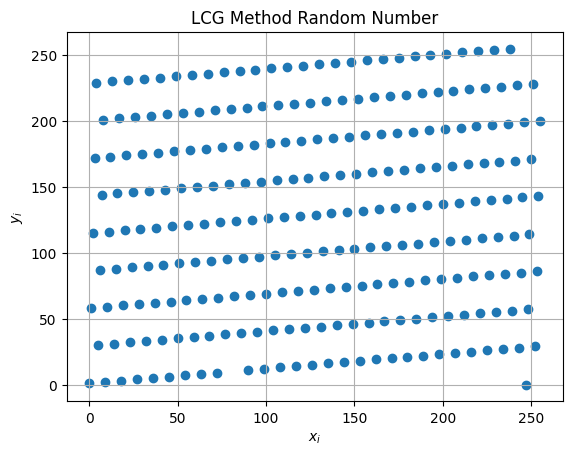

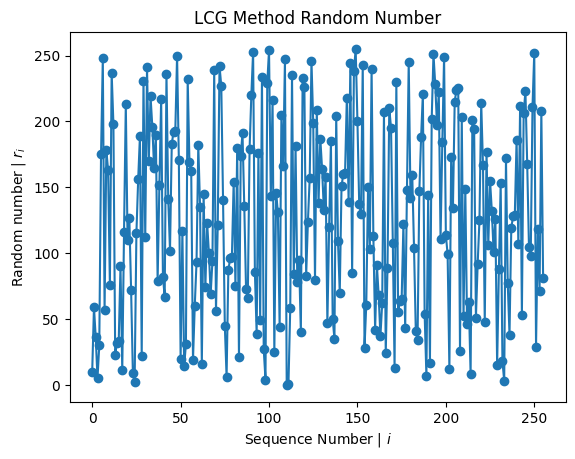

In [9]:
plt.scatter(randseq[:-1], randseq[1:])
plt.title("LCG Method Random Number")
plt.grid(True)
plt.xlabel("$x_{i}$")
plt.ylabel("$y_{i}$")

plt.show()

plt.plot(randseq, marker='o')
plt.title("LCG Method Random Number")
plt.xlabel("Sequence Number | $i$")
plt.ylabel("Random number | $r_{i}$")

plt.show()

In [10]:
# Step 5

import random
pyrandseq =[]
for i in range(0,256):
    pyrandseq.append(random.randint(0,255))

print(pyrandseq)

[145, 28, 10, 186, 102, 104, 117, 236, 67, 254, 94, 207, 186, 9, 127, 240, 135, 151, 158, 153, 63, 68, 229, 169, 92, 236, 122, 169, 51, 98, 74, 191, 193, 117, 166, 39, 234, 110, 187, 122, 232, 144, 99, 158, 191, 33, 213, 55, 208, 212, 99, 53, 186, 99, 156, 240, 252, 115, 88, 132, 37, 231, 129, 28, 159, 135, 255, 223, 144, 26, 192, 62, 193, 204, 18, 94, 180, 104, 131, 0, 186, 42, 161, 33, 133, 141, 112, 137, 60, 163, 241, 71, 77, 32, 164, 151, 2, 15, 54, 16, 233, 235, 219, 137, 50, 174, 156, 7, 66, 202, 168, 12, 95, 13, 135, 204, 44, 145, 85, 131, 6, 247, 21, 120, 64, 98, 247, 100, 224, 184, 95, 204, 146, 98, 155, 19, 110, 90, 239, 70, 238, 137, 142, 46, 154, 121, 141, 165, 90, 86, 4, 63, 95, 124, 138, 196, 33, 37, 222, 130, 16, 36, 138, 118, 142, 241, 34, 35, 223, 128, 43, 58, 45, 180, 127, 170, 8, 107, 181, 132, 138, 215, 35, 154, 21, 0, 44, 213, 219, 89, 52, 80, 253, 185, 209, 109, 254, 132, 227, 170, 225, 229, 14, 170, 39, 132, 222, 48, 65, 75, 163, 171, 75, 32, 66, 147, 77, 209, 15

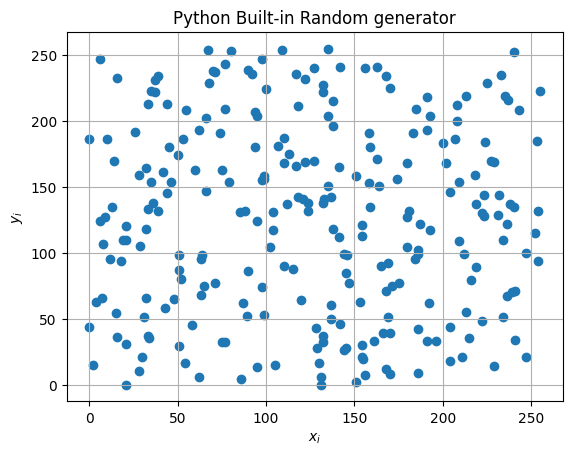

Text(0, 0.5, 'Random Number | $r_{i}$')

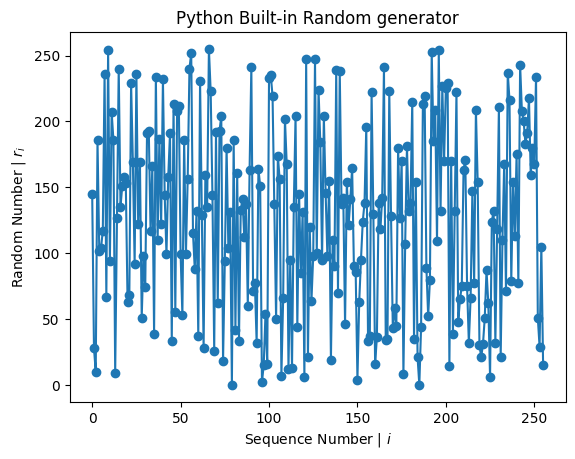

In [11]:
plt.scatter(pyrandseq[:-1], pyrandseq[1:])
plt.title("Python Built-in Random generator")
plt.grid(True)
plt.xlabel("$x_{i}$")
plt.ylabel("$y_{i}$")

plt.show()

plt.plot(pyrandseq, marker="o")
plt.title("Python Built-in Random generator")
plt.xlabel("Sequence Number | $i$")
plt.ylabel("Random Number | $r_{i}$")

In [12]:
Trm = 2**64 ; Tra = 6364136223846793005 ; Trc = 1442695040888963407 ; Trr1 = 123456789123456789

TrLCGrandseq = [Trr1]
for i in range(0, 255):
    TrLCGrandseq.append((((TrLCGrandseq[i] * Tra) + Trc) % Trm))

print(TrLCGrandseq)
print(len(randseq))
print(len(pyrandseq))
print(len(TrLCGrandseq))

[123456789123456789, 1974967775179612928, 17000411766270031, 4947572787859540018, 18301065199456780313, 1611843208282729652, 10017543145847843059, 9324159729080467718, 14834053416243669341, 14951765542847801768, 14345358859956284375, 12157838781753794330, 18088047471591153377, 5138465325727108572, 6859406885854991611, 11177982742281516654, 16127660634120873125, 15963154232543481168, 1567031760281110623, 9779108106302954242, 12981840337362665129, 4167323536590494724, 3254096470599346691, 17365389442636734678, 2704936724817424621, 3626605224491953656, 5194272480208133607, 17126045748993973226, 11514582039928782705, 8303683572142487340, 14653654350029555723, 7696477223228399678, 15858055659222773301, 1307027068776836000, 13385966911310122095, 1082078978597093842, 1950266206366302521, 1427890445743783764, 4208148525431361299, 9950618520005448870, 14319772378969439357, 13992339317888673352, 920910733882635255, 4643370947872173242, 14391016945562657793, 3032818063282852988, 11318858709109464

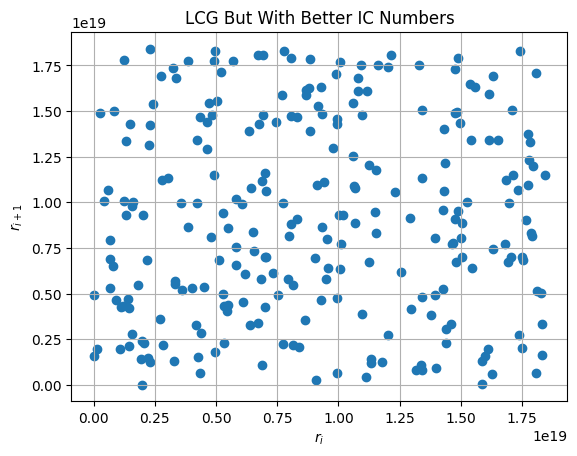

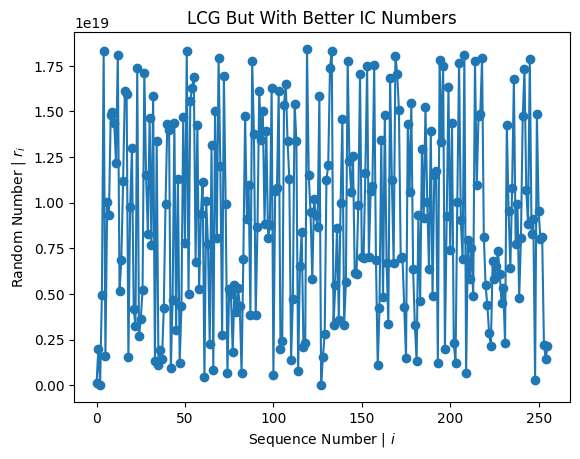

In [13]:
plt.scatter(TrLCGrandseq[:-1], TrLCGrandseq[1:])
plt.title("LCG But With Better IC Numbers")
plt.xlabel("$r_{i}$")
plt.ylabel("$r_{i+1}$")
plt.grid(True)

plt.show()

plt.plot(TrLCGrandseq, marker="o")
plt.title("LCG But With Better IC Numbers")
plt.xlabel("Sequence Number | $i$")
plt.ylabel("Random Number | $r_{i}$")

plt.show()

Note: to learn more about good choice of initial conditions for LCG method, read about "Hull-Dobell conditions".

#### 4.2.3 Assessing Randomness and unformity


Computer's random numbers are generated according to a definite rule, so the numbers of the sequence must correlate with each other. This can affect a simulation that assumes random evens. So it is wise to test a random-number generator to obtain a numerical measure of its unifromity and randomness.

1. most obvious test for randomness and uniformity is to just look at generated numbers. Below is some output from pythons random method. if you look, you will immediately know that they all lie between 0 and 1, that they appear to differ from each other.

In [14]:
import random
randlist = []
for i in range(30):
    randlist.append(random.random())
print(randlist)

[0.7843459289446644, 0.37961218143398867, 0.7123427168847455, 0.3995144684959868, 0.8102336821261042, 0.9058300418693584, 0.21055821709276223, 0.9870840215874247, 0.9586669531756176, 0.4241185035338051, 0.13769723143562718, 0.6609732616305953, 0.34077138690529774, 0.7439127857842918, 0.24089097865627118, 0.6460449982566446, 0.042223734887392284, 0.16622511003383988, 0.7553410323902982, 0.2725873496029608, 0.1643815714718896, 0.5848625925267386, 0.6576502837130775, 0.7489804527603917, 0.0003449454787951556, 0.8850855996018517, 0.6909621950391553, 0.3559260963865122, 0.5775167969847285, 0.5366873985397165]


2. a quick visual test is to plot the same list with $r_i$ vs $i$ and observe how there appears to be a uniform distribution between 0 and 1 and no correlation between points.

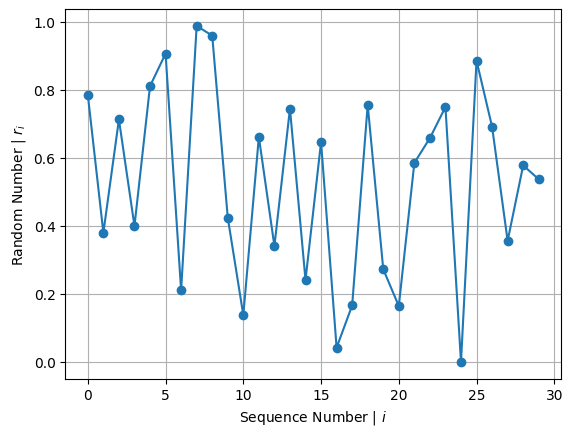

In [15]:
plt.plot(randlist, marker = "o")
plt.xlabel("Sequence Number | $i$")
plt.ylabel("Random Number | $r_{i}$")
plt.grid(True)

3. a simple test of uniformity evaluates the *k*th moment of distribution:

\begin{equation}
\langle x^k \rangle =
\frac{1}{N}\sum_{i=1}^{N} x_i^k .
\tag{4.5}
\end{equation}

If the numbers are distributed *uniformly*, then (4.5) is approximately the moment of the distribution function $P(x)$:
\begin{equation}
\frac{1}{N}\sum_{i=1}^{N} x_i^k
\simeq
\int_{0}^{1} dx\, x^k P(x)
\simeq
\frac{1}{k+1}
+
O\!\left(\frac{1}{\sqrt{N}}\right) .
\tag{4.6}
\end{equation}

if (4.6) holds for our generator, then the distribution is uniform. If the deviation from (4.6) varies as $1/\sqrt{N}$, then the distribution is also random because the $1/\sqrt{N}$ result derives from assuming randomness.

4. A correlation test checks whether nearby random numbers in a sequence are independent. For a sequence $x_i$, we calculate

\begin{align*}
    C(k) = \frac{1}{N} \sum_{i = 0}^{N} x_i x_{i+k}
    \tag{4.7}
\end{align*}

where $k$ is the separation between two numbers in the sequence. for example $C(1)$ compares each number with the next one, and $C(2)$ compares it with the number two steps later. if the numbers are independent and uniformly distributed in $[0,1]$, then $x_i$ and $x_{i+k}$ behave like two independent variables $x$ and $y$, so

\begin{align*}
    C(k) \approx \int_0^1 \int_0^1 xy dxdy = \frac{1}{4}
\end{align*}

therefore, for a good random-number generator, $C(k)$ should be close to $1/4$ . A large deviation from $1/4$ shows that the sequence may have unwanted correlations.

5. an effective test is performed by making a scatterplot of ($x_i = r_{2i}$, $y_i = r_{2i+1}$) for many $i$ values. then see if your points have noticeable regularity.

### Example: Uniformity and Correlation Tests

For the sequence

$$
x = [0.2,\ 0.4,\ 0.6,\ 0.8]
$$

For the **moment test** with \(k=1\):

$$
\langle x \rangle = \frac{1}{4}(0.2+0.4+0.6+0.8)=0.5
$$

For a uniform distribution on \([0,1]\), the expected value is

$$
\frac{1}{k+1}=\frac{1}{2}=0.5
$$

So the sequence passes this simple test for \(k=1\).

For the **correlation test** with separation \(k=1\):

$$
C(1)=\frac{1}{3}(0.2 \cdot 0.4 + 0.4 \cdot 0.6 + 0.6 \cdot 0.8)
$$

$$
C(1)=\frac{0.80}{3}\approx 0.267
$$

For independent uniform random numbers, we expect

$$
C(k)\approx \frac{1}{4}=0.25
$$

Since \(0.267\) is close to \(0.25\), the correlation is small, but the sample is too small to be reliable.

For the uniformity test, we calculate the sample moment

$$
\langle x^k \rangle_N=
\frac{1}{N}\sum_{i=1}^{N}x_i^k
$$

For a perfect uniform distribution on $[0,1]$,

$$
\langle x^k \rangle
=
\int_0^1 x^k dx
=
\frac{1}{k+1}
$$

Now define

$$
Y_i=x_i^k
$$

Then the test becomes the average of $N$ random variables:

$$
\langle x^k \rangle_N=
\frac{1}{N}\sum_{i=1}^{N}Y_i
$$

The variance of one sample is

$$
\sigma_Y^2
=
\langle Y_i^2 \rangle-\langle Y_i\rangle^2
=
\frac{1}{2k+1}
-
\left(\frac{1}{k+1}\right)^2
$$

When we average $N$ independent samples, the variance becomes

$$
\text{Var}\left(\frac{1}{N}\sum_{i=1}^{N}Y_i\right)
=
\frac{\sigma_Y^2}{N}
$$

Therefore the standard deviation, or typical error, is

$$
\sigma_{\langle x^k\rangle_N}
=
\frac{\sigma_Y}{\sqrt{N}}
$$

So,

$$
\boxed{
\frac{1}{N}\sum_{i=1}^{N}x_i^k
=
\frac{1}{k+1}
+
O\left(\frac{1}{\sqrt{N}}\right)
}
$$

So the error decreases like

$$
\boxed{\frac{1}{\sqrt{N}}}
$$

### 4.3: Random Walk



Consider a perfume molecule released in the frontof a classroom. It collides randomly with other molecules in the air and eventually reaches your nose. The problem is to determine how many collisions on the average a perfume molecule makes in traveling a distance $R$. You are given the fact that molecule travels an average distance $r_{rms}$ between collisions.

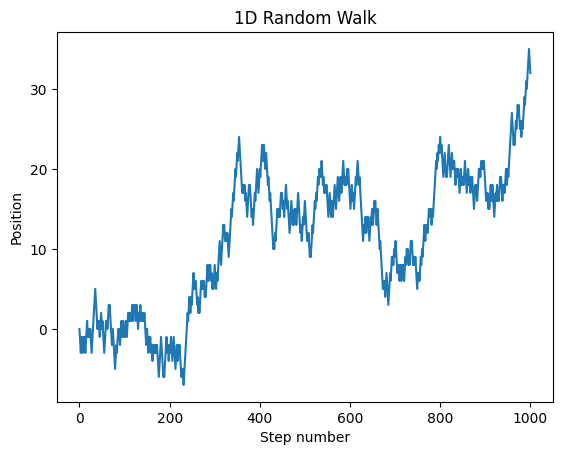

In [16]:
position = 0
positions = [position]

N = 1000  # number of steps

for i in range(N):
    step = random.choice([-1, 1])  # move left or right randomly
    position += step
    positions.append(position)

plt.plot(positions)
plt.xlabel("Step number")
plt.ylabel("Position")
plt.title("1D Random Walk")
plt.show()

#### 4.3.1: Random-Walk Simulations

There are number of ways to simulate a random walk with different assumptions yielding different physics. we present the simplest approach for a 2D walk, with a minimum of theory, and end up with a model for *normal diffusion*. Additional refinements including collisions within a moving medium, are so often called  *abnormal diffusion*.

normal diffusion: $\langle r^2(t) \rangle \propto t$

abnormal diffusion: $\langle r^2(t) \rangle \propto t^\alpha$

In our random-walk simulation, an artificial walker takes sequential stpes with direction of each step *independent* of the direction of the previous step. For our model, we start at the origin and take $N$ steps in the $xy$ plane of *lengths*:

\begin{align*}
    (\Delta x_1, \Delta y_1), \qquad (\Delta x_2, \Delta y_2), \qquad (\Delta x_3, \Delta y_3), ... \quad, \qquad (\Delta x_N, \Delta y_N) \quad .
    \tag{4.8}
\end{align*}

Although each step may be in a different direction, the distances along each Cartesian axis just add algebrically. The radial distance $R$ from the starting point after $N$ step is:

\begin{align*}
    R^2 &= (\Delta x_1 + \Delta x_2 +...+ \Delta x_N)^2 + (\Delta y_1 + \Delta y_2 +...+ \Delta y_N)^2 \newline
    &= \Delta x_1^2 + \Delta x_2^2 + ... \Delta x_N^2 + 2 \Delta x_1 \Delta x_2 + 2 \Delta x_1 \Delta x_3 + 2 \Delta x_2 \Delta x_3 + ...
    \tag{4.9}
\end{align*}

If the walk is random, the particle is equally likely to travel in any direction at each step. If we take the average of a large number of such random steps, all the cross terms in (4.9) will vanish and we will be left with:

\begin{align*}
    R_{rms}^2 &\simeq \langle \Delta x_1^2 + \Delta x_2^2 + ... + \Delta x_N^2 + \Delta y_1^2 + \Delta y_2^2 + ... + \Delta y_N^2 \rangle \newline

    &= \langle \Delta x_1^2 + \Delta y_1^2 \rangle + \langle \Delta x_2^2 + \Delta y_2^2 \rangle + ... \newline
    &= N \langle r^2 \rangle = Nr_{rms}^2 \newline
    &\Rightarrow R_{rms} \simeq \sqrt{N}r_{rms}
    \tag{4.10}
\end{align*}

where $r_{rms} = \sqrt{\langle r^2 \rangle}$ is the *root-mean-square* step size.

so in order to summarize, if the walk is random, then we expect that after a large number of steps the average *vector* distance from the origin will vanish.

\begin{align*}
    \langle \bold{R} \rangle = \langle x \rangle \mathcal{\bold{i}} + \langle y \rangle \mathcal{\bold{j}} \simeq = 0
    \tag{4.11}
\end{align*}

yet $R_{rms} = \sqrt{\langle R_i^2 \rangle}$ does not vanish. equation 4.10 indicates that the average *scalar* distance from the origin is $\sqrt{N}r_{rms}$, wherer each step is of average length $r_{rms}$. the vector endpoint will be distributed uniformly in all quadrants, and so the displacement vector averages to zero, but the averate length of that vector does not. for large $N$ values, $\sqrt{N}r_{rms} \ll Nr_{rms}$ (the value if all steps were in one direction on a straight line), but does not vanish. practical simulations agree with this theory, but rarely perfectly, with a level of agreements.

#### 4.3.2: Implementation: Random walk

when using your computer to simulate a random walk, you should expect to obtain equation 4.10 only as the average displacement averaged over many trials, not necessarily answer for each trial.

start at the origin and take a 2D random walk with your computer. ***here i work with normalized-diagonal random walk***

1. to increase the amount of randomness, independently choose random values for $\Delta x'$ and $\Delta y'$ in the range $[-1,1]$. then normalize them so that each step is of unit length

\begin{align*}
\Delta x = \frac{1}{L} \Delta x' \quad , \qquad \Delta y = \frac{1}{L} \Delta y' \quad , \qquad L = \sqrt{\Delta x'^2 + \Delta y'^2}
\tag{4.12}
\end{align*}



In [17]:
posx = [0] ; posy= [0]

N = 1000
for i in range(0, N):
    dx_prime = random.choice([-1, 0, 1])
    dy_prime = random.choice([-1, 0, 1])
    while dx_prime == dy_prime == 0 :
        dx_prime = random.choice([-1, 0, 1])
        dy_prime = random.choice([-1, 0, 1])

    length = np.sqrt(dx_prime**2 + dy_prime**2)

    dx = dx_prime / length
    dy = dy_prime / length

    posx.append(posx[i] + dx)
    posy.append(posy[i] + dy)

print(posx)
print(posy)

[0, np.float64(-0.7071067811865475), np.float64(-1.7071067811865475), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(0.29289321881345254), np.float64(1.0), np.float64(1.7071067811865475), np.float64(2.414213562373095), np.float64(1.7071067811865475), np.float64(1.7071067811865475), np.float64(1.7071067811865475), np.float64(1.0), np.float64(1.7071067811865475), np.float64(2.414213562373095), np.float64(3.1213203435596424), np.float64(2.1213203435596424), np.float64(2.82842712474619), np.float64(2.1213203435596424), np.float64(1.414213562373095), np.float64(2.1213203435596424), np.float64(2.82842712474619), np.float64(2.82842712474619), np.float64(2.82842712474619), np.float64(2.82842712474619), np.float64(2.82842712474619), np.float64(2.1213203435596424), np.float64(1.414213562373095), np.float64(2.1213203435596424), np.float64(3.1213203435596424), np.float64(2.1213203435596424), np.float64(2.1213203435596424), np.float

2. use plotting program to draw maps of several independent 2D random walks, each of 1000 steps. Using evidence from your simulations, comment on wether these look like you would expect for a random walk.

4.242640687119291 -12.485281374238593


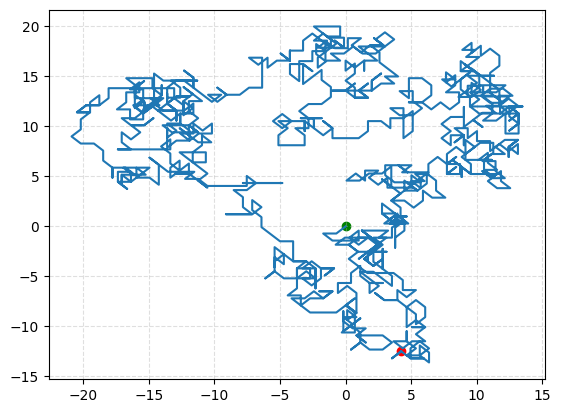

In [18]:
plt.plot(posx, posy)
plt.grid(True, ls = "--", alpha = 0.4)
plt.scatter(posx[-1], posy[-1], color = "red")
plt.scatter(posx[0], posy[0], color = "green")

print(posx[-1], posy[-1])

3. If you have walker taking $N$ steps in a single trial, then conduct a total number $K \simeq \sqrt{N}$ of trials. Each trial should have $N$ steps and start with a different seed.

[np.float64(-13.464466094067262), np.float64(-5.849242404917501), np.float64(44.6066017177982), np.float64(21.75735931288071), np.float64(-4.0502525316941735), np.float64(-4.363961030678931), np.float64(2.878679656440356), np.float64(36.4558441227157), np.float64(-33.24264068711929), np.float64(28.07106781186547), np.float64(0.19238815542511922), np.float64(-20.899494936611653), np.float64(-11.091883092036793), np.float64(7.44365081389595), np.float64(-6.0502525316941735), np.float64(29.254833995938988), np.float64(-29.828427124746177), np.float64(12.920310216782983), np.float64(-32.97056274847715), np.float64(0.46446609406725603), np.float64(-17.878679656440358), np.float64(13.37258300203048), np.float64(13.192388155425112), np.float64(22.74873734152917), np.float64(-20.849242404917483), np.float64(-2.7279220613578645), np.float64(-15.506096654409866), np.float64(-4.878679656440358), np.float64(-25.707106781186575), np.float64(37.40559159102152), np.float64(-13.12132034355964)]
[np.fl

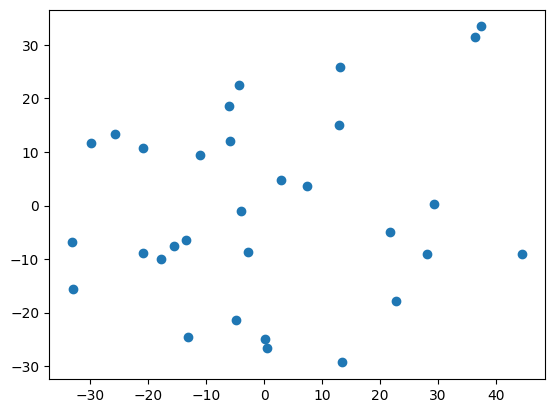

In [19]:
N = 1000
K = int(np.sqrt(N))

Kposx = []
Kposy = []

dx_step_t = []
dy_step_t = []

for j in range(0, K):
    posx = [0] ; posy = [0]
    dx_step = []
    dy_step = []

    random.seed(j + 1000)
    for i in range(0, N):
        dx_prime = random.choice([-1, 0, 1])
        dy_prime = random.choice([-1, 0, 1])
        while dx_prime == dy_prime == 0 :
            dx_prime = random.choice([-1, 0, 1])
            dy_prime = random.choice([-1, 0, 1])

        length = np.sqrt(dx_prime**2 + dy_prime**2)

        dx = dx_prime / length
        dy = dy_prime / length

        posx.append(posx[i] + dx)
        posy.append(posy[i] + dy)

        dx_step.append(dx)
        dy_step.append(dy)

    Kposx.append(posx[-1])
    Kposy.append(posy[-1])
    dx_step_t.append(dx_step)
    dy_step_t.append(dy_step)

print(Kposx)
print(Kposy)
print(len(Kposx))
plt.scatter(Kposx, Kposy)

4. calculate the mean square distance $R^2$ for each trial and then take the average of $R^2$ for all your $K$ trials:

\begin{align*}
    \langle R^2 (N) \rangle = \frac{1}{K}\sum_{k=1}^{K} R_k^2  (N)
        \tag{4.13}
\end{align*}

In [20]:
Rsqr = []
Rsqr_sum = 0
for i in range(0, len(Kposx)):
    Rsqr.append(Kposx[i]**2 + Kposy[i]**2)
    Rsqr_sum += Rsqr[i]

Rmean = Rsqr_sum / K
Rrms = np.sqrt(Rmean)
print(Rsqr)
print(Rsqr_sum)
print(Rsqr_sum/ K)

[np.float64(223.08116907963228), np.float64(181.1400435826778), np.float64(2070.374675043082), np.float64(497.6770567850255), np.float64(17.30656582404841), np.float64(528.7725112145306), np.float64(31.80194846605358), np.float64(2320.3515139147185), np.float64(1152.103463656219), np.float64(868.9848480983496), np.float64(624.6059889731611), np.float64(552.5096679918778), np.float64(210.71363671148544), np.float64(69.30534033477234), np.float64(382.8111831820432), np.float64(855.9362235398478), np.float64(1026.3044737829944), np.float64(394.699351361613), np.float64(1332.1950929411162), np.float64(704.3502884254444), np.float64(420.65476220843937), np.float64(1038.1194821096449), np.float64(842.222438151585), np.float64(836.1005050633878), np.float64(511.7472580451134), np.float64(82.89321881345263), np.float64(298.7481245968907), np.float64(478.96342007353996), np.float64(841.3553390593293), np.float64(2517.0794359760757), np.float64(775.606855524938)]
22688.515882531094
731.887609113

5. check the validity of the assumptions made in deriving the theoritical result (4.20) by checking how well

\begin{align*}
    \frac{\langle \Delta x_i \Delta x_{j\neq i} \rangle}{R^2} \simeq \frac{\langle \Delta x_i \Delta y_i \rangle}{R^2} \simeq 0
    \tag{4.14}
\end{align*}

do your checking by both a single (long) run and for the average over trials.

In [21]:
dx_m_dx = 0
dy_m_dx = 0

a = 15

for i in range(0, N):
    for j in range(0, N):
        if i == j : pass
        else:
            dx_m_dx += dx_step_t[a][i] * dx_step_t[a][j]

for i in range(0, N):
    for j in range(0, N):
        dy_m_dx += dy_step_t[a][i] * dx_step_t[a][j]

print(dx_m_dx / Rsqr[a] , dy_m_dx / Rsqr[a])

avdx_m_dx = 0
avdy_m_dx = 0

for a in range(0, K):
    dx_m_dx = 0
    dy_m_dx = 0

    for i in range(0, N):
        for j in range(0, N):
            if i != j : 
                dx_m_dx += (dx_step_t[a][i] * dx_step_t[a][j])
            dy_m_dx += dy_step_t[a][i] * dx_step_t[a][j]
avdx_m_dx = dx_m_dx / (N * (N-1))
avdy_m_dx = dy_m_dx / (N**2)


print(avdx_m_dx / K , avdy_m_dx / K)

0.4087282469284119 0.010305413642930446
-1.0569632614604534e-05 1.0397575993137976e-05


6. plot the root-mean-square distance $R_{rms} = \sqrt{\langle R^2 (N) \rangle}$ as a function of $\sqrt{N}$. values of $N$ should start with a small number, where $R \simeq \sqrt{N}$ is not expected to be accurate, and end at a quite large value, where two or three places of accuracy should be expected on the average.

In [22]:
def randwalk2d(N):

    K = int(np.sqrt(N))

    Kposx = []
    Kposy = []

    dx_step_t = []
    dy_step_t = []

    for j in range(0, K):
        posx = [0] ; posy = [0]
        dx_step = []
        dy_step = []

        random.seed(j + 1000)
        for i in range(0, N):
            dx_prime = random.choice([-1, 0, 1])
            dy_prime = random.choice([-1, 0, 1])
            while dx_prime == dy_prime == 0 :
                dx_prime = random.choice([-1, 0, 1])
                dy_prime = random.choice([-1, 0, 1])

            length = np.sqrt(dx_prime**2 + dy_prime**2)

            dx = dx_prime / length
            dy = dy_prime / length

            posx.append(posx[i] + dx)
            posy.append(posy[i] + dy)

            dx_step.append(dx)
            dy_step.append(dy)

        Kposx.append(posx[-1])
        Kposy.append(posy[-1])

        dx_step_t.append(dx_step)
        dy_step_t.append(dy_step)

    Rsqr = []
    Rsqr_sum = 0
    for i in range(0, len(Kposx)):
        Rsqr.append(Kposx[i]**2 + Kposy[i]**2)
        Rsqr_sum += Rsqr[i]

    Rmean = Rsqr_sum / K
    Rrms = np.sqrt(Rmean)

    avdx_m_dx = 0
    avdy_m_dx = 0

    # for a in range(0, K):
    #     for i in range(0, N):
    #         for j in range(0, N):
    #             avdy_m_dx += (dy_step_t[a][i] * dx_step_t[a][j]) / Rsqr[a]
    #             if i == j : pass
    #             else:
    #                 avdx_m_dx += (dx_step_t[a][i] * dx_step_t[a][j]) / Rsqr[a]

    return [[Kposx, Kposy], Rrms, [dx_step_t, dy_step_t]]

[np.float64(1.8257418583505538),
 np.float64(4.785956789077419),
 np.float64(11.882965847107696),
 np.float64(18.158452784912914),
 np.float64(27.053421393862667),
 np.float64(47.13707159787169),
 np.float64(93.75072119805762)]

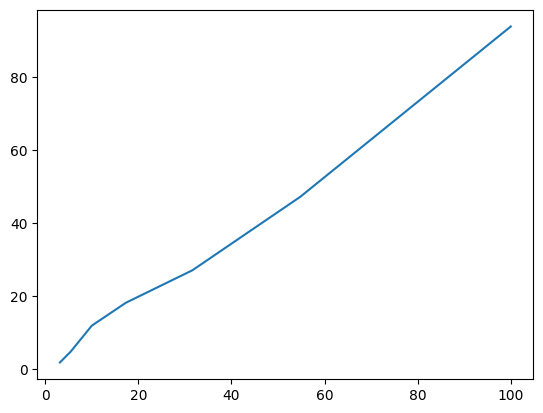

In [23]:
N_values = [10, 30, 100, 300, 1000, 3000, 10000]

N0rw = randwalk2d(N_values[0])
N1rw = randwalk2d(N_values[1])
N2rw = randwalk2d(N_values[2])
N3rw = randwalk2d(N_values[3])
N4rw = randwalk2d(N_values[4])
N5rw = randwalk2d(N_values[5])
N6rw = randwalk2d(N_values[6])

RrmsList = [N0rw[1],N1rw[1],N2rw[1],N3rw[1],N4rw[1],N5rw[1],N6rw[1]]
plt.plot(np.sqrt(N_values), RrmsList)
RrmsList

7. repeat the preceding and following analysis for a 3D walk as well. (later)

### 4.5 Spontaneous Decay (Problem)

Your problem is to simulate how a small number $N$ of radioactive particles decay. In particular, you are to determine when radioactive decay looks like exponential decay and when it looks *stochastic* (containing elemnts of chance). Because the exponential decay law is a large-number eapproximation to a natural process that always leads to only a small number of nuclei remaining, our simulation should be closer to nature than is the exponential law. (fig 4.6)

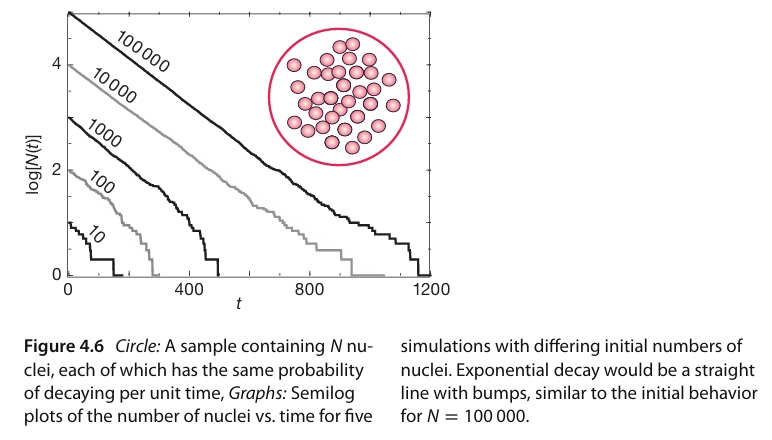

If you "listen" to the output of the decay simulation code, what you will hear sounds very much like a Geiger counter, and intuitively convincing demonstration of the realism of the simulation.

Spontaneou decay is a natural process in which a particle with no external stimulation, decays into other particles. Although the probability of decay of any one particle in any time interval is constant, just when it decays is a radnom event.

Because the exact moment when any one particle decays is alwyas random, and because one nucleus does not influence another nucleus, the probability of decay is not influenced by how long the particle has been around or wether some other particles have decayed. The probability $\mathcal{P}$ of any one particle decaying per unit time interval is a constant. As the total number $N$ of particles decreases with time, so will the number that decay per unit time, but the probability of any one particle decaying in some time interval remains the same as long as that particle exists.

#### 4.5.1: Discrete Decay (Model)

Imagine having a sample containing $N(t)$ radioactive nuclei at time $t$. Let $\Delta N$ be the number of particles that decay in some small time interval $\Delta t$. We convert statement "The Probability $\mathcal{P}$ of any one particle decaying per unit time is a constant" into eqaution:

\begin{align*}
    &\mathcal{P} = \frac{\Delta N(t) / N(t)}{\Delta t} = - \lambda \tag{4.15} \newline
    &\Rightarrow \frac{\Delta N(t)}{\Delta t} = -\lambda N(t) \tag{4.16}
\end{align*}

where the constant $\lambda$ is called the *decay rate*, having units of inverse time, and the minus sign indicates a decreasing number. Because $N(t)$ decreases over time, the *activity* $\Delta N(t) / \Delta t$ (or called the decay rate) also decreases over time. In addition, because the total activity is proportional to the total number of particles present, it is too stochastic with an exponential-like decay in time. (Actually, because the number of decays $\Delta N(t)$ is proportional to the difference in random numbers, its tends to show even larger statistical fluctuations than does $N(t)$)

Equation 4.27 is a *finite-difference equation* relating the experimentally quantities $N(t), \Delta N(t),$ and $\Delta t$. Although a difference equation cannot be integrated the way a differential equation can, it can be simulated numerically. Because the process is random, we cannot predict a single value for $\Delta N(t)$, although we can predict the average number of decays when observations are made of many identical systems of $N$ decaying particles.

#### 4.5.2: Continuous Decay (Model)

When the number of particles $\N \rightarrow \infty$ and the observation time interval $\Delta t \rightarrow 0$, our difference equation becomes a differential equation, and we obtain the familiar exponential decay law 4.16 :

\begin{align*}
\frac{\Delta N(t)}{\Delta t} \rightarrow \frac{dN(t)}{dt} = -\lambda N(t) \tag{4.17}
\end{align*}

This can be integrated to obtain the time dependence of the total number of particles and of the activity:

\begin{align*}
    N(t) &= N(0)e^{-\lambda t} = N(0)e^{-t/\tau} \tag{4.18} \\
    \frac{dN(t)}{dt} 
    &= -\lambda N(0)e^{-\lambda t} 
    = \left.\frac{dN}{dt}\right|_{t=0} e^{-\lambda t} \tag{4.19}
\end{align*}

in this limit, we can identify the decay rate $\lambda$ with the inverse life time:

\begin{align*}
    \lambda = \frac{1}{\tau}
\end{align*}

We see from its derivation that the exponential decay is a good description of nature for a large number of particles where $\Delta N / N \simeq 0$. however, in nature $N(t)$ can be a small number, and in that case we have a statistical and not continuous process. The basic law of nature 4.15 is always valid, but as we will see in the simulations, the exponential decay becomes less and less acurate as the number of particles gets smaller and smaller.

#### 4.5.3: Decay Simulation with Geiger Counter Sound

A program for simulating radioactive decay is surprisingly simple but not without its subtleties. We increase time in discrete steps of $\Delta t$ , and for each time interval we count the number of nuclei that have decayed during that $\Delta t$. The simulation quits when there are not nuclei left to decay. Such being the case, we have an outer loop over the time steps $\Delta t$ and an inner loop over the remaining nuclei for each time step.

When we pick a value for the decay rate $\lambda = 1/\tau$ to use in our simulation, we are setting the scale for times. If the actual decay rate is $\lambda = 0.3 \times 10^{6}\ \mathrm{s}^{-1}$ and if we decide to measure times in units of $10^{-6}\ \mathrm{s}$, then we will choose random numbers $0 \leq r_i \leq 1$, which leads to $\lambda$ values lying someplace near the middle of the range, e.g. $\lambda \simeq 0.3$. Alternatively, we can use a value $\lambda = 0.3 \times 10^{6}\ \mathrm{s}^{-1}$ in our simulation and then scale the random numbers to the range $0 \leq r_i \leq 10^{6}$. However, unless you plan to compare your simulation to experimental data, you do not have to worry about the scale for time but instead should focus on the physics behind the slopes and relative magnitudes of the graphs.

### 4.6 Decay Implementation and Visualization

Write a program to simulate the radioactive decay. You should obtain results like those in Figure 4.6.

1. Plot the logarithm of the number left $\ln N(t)$ and the logarithm of the decay rate $\ln[\Delta N(t)/\Delta t]$ with $\Delta t = 1$ vs. time. Note that the simulation measures time in steps of $\Delta t$ generation number.

2. Check that you obtain what looks like the exponential decay when you start with large values for $N(0)$, but that the decay displays its stochastic nature for small $N(0)$. Large $N(0)$ values are also stochastic; they just do not look like it.

3. Create two plots, one showing that the slopes of $N(t)$ vs. $t$ are independent of $N(0)$ and another showing that the slopes are proportional to the value chosen for $\lambda$.

4. Create a plot showing that within the expected statistical variations, $\ln N(t)$ and $\ln \Delta N(t)$ are proportional.

5. Explain in your own words how a process that is spontaneous and random at its very heart can lead to the exponential decay.

6. How does your simulation show that the decay is exponential-like and not a power law such as $N = \beta t^{-\alpha}$?

In [25]:
lambd = 0.3 * 10**6 ; N = 10000

dt = 10**(-6)

def decayfunc(lambd, N, dt):
    t = 0
    hist_N = [N]
    hist_deltaN = [0]
    hist_t = [t]

    p = lambd * dt
    if p > 1 or p < 0 :
        raise ValueError("Decay probability is larger than 1. Choose smaller dt.")
    
    for i in range(0, 1):
        while N > 0 :
            DeltaN = 0
            for i in range(0, N):
                ri= random.random()
                if ri < p :
                    DeltaN += 1

            N = N - DeltaN
            t += dt

            hist_N.append(N)
            hist_deltaN.append(DeltaN)
            hist_t.append(t)
        
        hist_N = np.array(hist_N)
        hist_deltaN = np.array(hist_deltaN)
        hist_t = np.array(hist_t)

    return [t, N, hist_N, hist_deltaN, hist_t]

res = decayfunc(lambd, N, dt)
print(res[0], res[1])
print(res[2])
print(res[3])
print(res[4])
print(len(res[2]), len(res[3]), len(res[4]))

2.5000000000000008e-05 0
[10000  7018  4951  3470  2469  1718  1241   886   614   456   306   225
   159   118    85    57    44    31    23    15    10     6     4     1
     1     0]
[   0 2982 2067 1481 1001  751  477  355  272  158  150   81   66   41
   33   28   13   13    8    8    5    4    2    3    0    1]
[0.0e+00 1.0e-06 2.0e-06 3.0e-06 4.0e-06 5.0e-06 6.0e-06 7.0e-06 8.0e-06
 9.0e-06 1.0e-05 1.1e-05 1.2e-05 1.3e-05 1.4e-05 1.5e-05 1.6e-05 1.7e-05
 1.8e-05 1.9e-05 2.0e-05 2.1e-05 2.2e-05 2.3e-05 2.4e-05 2.5e-05]
26 26 26


In [36]:
import random
import time
import numpy as np
import pygame


# -----------------------------
# Geiger sound setup
# -----------------------------
pygame.mixer.init(frequency=44100, size=-16, channels=2, buffer=512)


def make_geiger_click(sample_rate=44100):
    duration = 0.004  # seconds
    t = np.linspace(0, duration, int(sample_rate * duration), False)

    # Short noisy high-frequency click
    noise = np.random.uniform(-1, 1, len(t))
    envelope = np.exp(-t * 2500)

    wave = noise * envelope
    wave = (wave * 32767).astype(np.int16)

    # Stereo sound
    stereo_wave = np.column_stack((wave, wave))

    return pygame.sndarray.make_sound(stereo_wave)


click_sound = make_geiger_click()


def play_geiger_clicks(DeltaN, step_audio_time=0.025):
    """
    DeltaN may be very large, so we compress many decays
    into a smaller number of audible Geiger clicks.
    """

    if DeltaN <= 0:
        time.sleep(step_audio_time)
        return

    # Convert number of decays into audible clicks
    click_scale = 0.002
    expected_clicks = DeltaN * click_scale

    audible_clicks = np.random.poisson(expected_clicks)

    # Prevent audio overload
    audible_clicks = min(audible_clicks, 8)

    click_times = sorted(
        random.uniform(0, step_audio_time)
        for _ in range(audible_clicks)
    )

    previous_time = 0

    for click_time in click_times:
        time.sleep(click_time - previous_time)

        click_sound.set_volume(random.uniform(0.4, 1.0))
        click_sound.play()

        previous_time = click_time

    time.sleep(step_audio_time - previous_time)


# -----------------------------
# Your decay simulation
# -----------------------------
lambd = 0.3 * 10**6
N = 1000000
dt = 10**(-6)


def decayfunc(lambd, N, dt, sound=True):
    t = 0

    hist_N = [N]
    hist_deltaN = [0]
    hist_t = [t]

    p = lambd * dt

    if p > 1 or p < 0:
        raise ValueError("Decay probability is larger than 1. Choose smaller dt.")

    while N > 0:
        DeltaN = 0

        for i in range(N):
            ri = random.random()

            if ri < p:
                DeltaN += 1

        N = N - DeltaN
        t += dt

        hist_N.append(N)
        hist_deltaN.append(DeltaN)
        hist_t.append(t)

        if sound:
            play_geiger_clicks(DeltaN)

    hist_N = np.array(hist_N)
    hist_deltaN = np.array(hist_deltaN)
    hist_t = np.array(hist_t)

    return [t, N, hist_N, hist_deltaN, hist_t]


res = decayfunc(lambd, N, dt, sound=True)

print(res[0], res[1])
print(res[2])
print(res[3])
print(res[4])
print(len(res[2]), len(res[3]), len(res[4]))

pygame.time.wait(200)
pygame.quit()

3.799999999999999e-05 0
[1000000  700065  489954  343136  239882  167769  117832   82169   57549
   40145   28180   19670   13828    9600    6800    4751    3312    2267
    1608    1117     767     536     393     265     182     115      83
      59      38      27      15       7       5       4       3       2
       1       1       0]
[     0 299935 210111 146818 103254  72113  49937  35663  24620  17404
  11965   8510   5842   4228   2800   2049   1439   1045    659    491
    350    231    143    128     83     67     32     24     21     11
     12      8      2      1      1      1      1      0      1]
[0.0e+00 1.0e-06 2.0e-06 3.0e-06 4.0e-06 5.0e-06 6.0e-06 7.0e-06 8.0e-06
 9.0e-06 1.0e-05 1.1e-05 1.2e-05 1.3e-05 1.4e-05 1.5e-05 1.6e-05 1.7e-05
 1.8e-05 1.9e-05 2.0e-05 2.1e-05 2.2e-05 2.3e-05 2.4e-05 2.5e-05 2.6e-05
 2.7e-05 2.8e-05 2.9e-05 3.0e-05 3.1e-05 3.2e-05 3.3e-05 3.4e-05 3.5e-05
 3.6e-05 3.7e-05 3.8e-05]
39 39 39


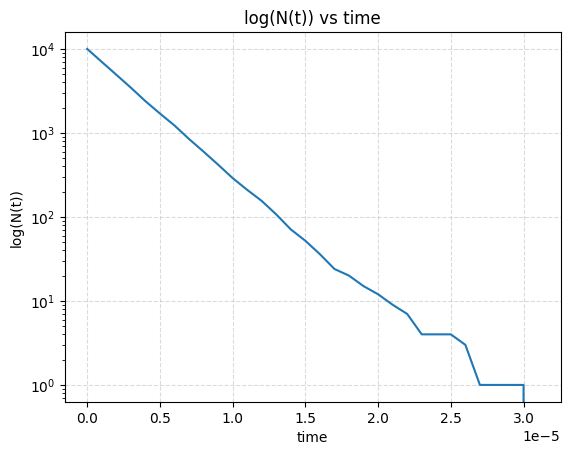

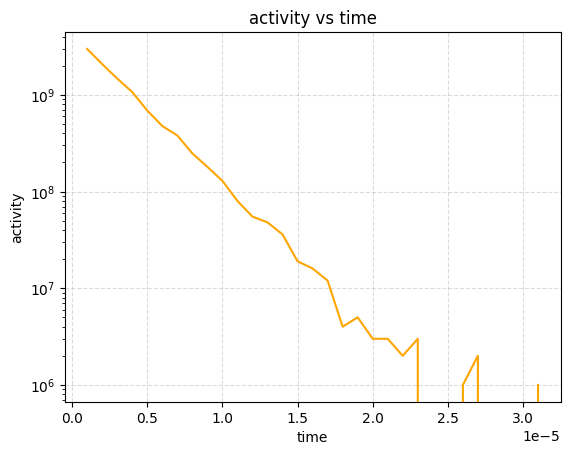

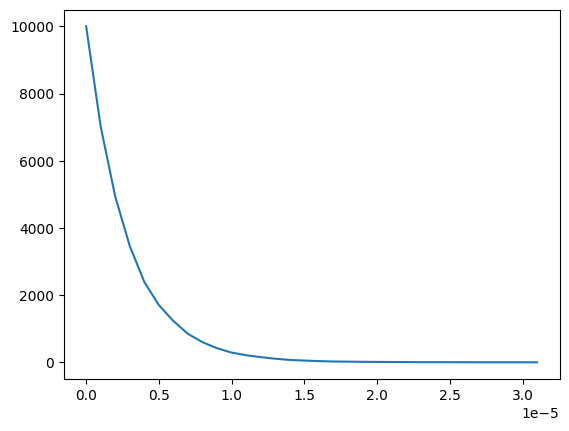

In [ ]:
x = res[4] ; y = res[2]

plt.semilogy(x, y, label="N(t) vs t")
plt.title("log(N(t)) vs time")
plt.xlabel("time")
plt.ylabel("log(N(t))")
plt.grid(True, ls="--", alpha = 0.45)
plt.show()

decay_rate = res[3][1:] / dt

plt.semilogy(x[1:], decay_rate, label="activity", color = "orange")
plt.title("activity vs time")
plt.xlabel("time")
plt.ylabel("activity")
plt.grid(True, ls="--", alpha = 0.45)
plt.show()

plt.plot(x, res[2])

<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4316\1442719514.py:23: SyntaxWarning: invalid escape sequence '\D'
  plt.loglog(x, y, label = f"log(N(t)) vs log($\Delta$ N(t)) for N0 = {totres[i][2][0]}")


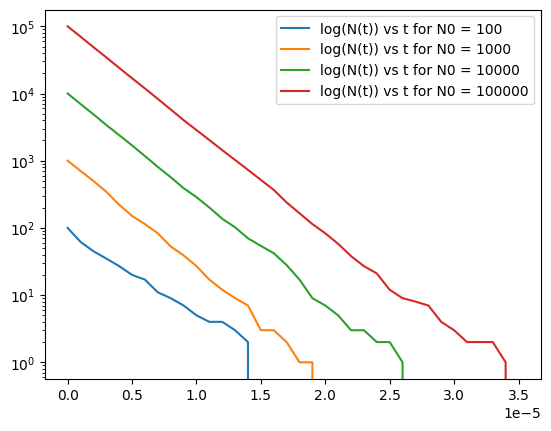

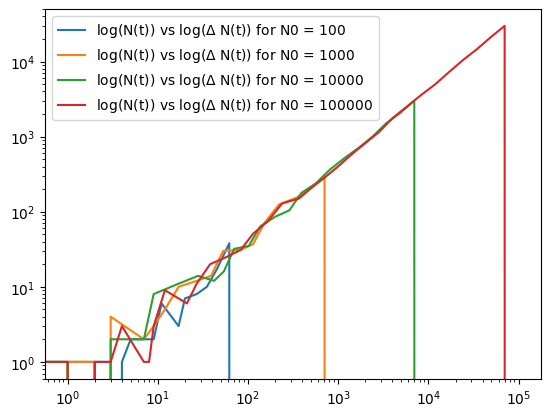

In [ ]:
N0val = [100, 1000, 10000, 100000]
lambd = 0.3 * 10**6
dt = 10**(-6)

res0 = decayfunc(lambd, N0val[0], dt)
res1 = decayfunc(lambd, N0val[1], dt)
res2 = decayfunc(lambd, N0val[2], dt)
res3 = decayfunc(lambd, N0val[3], dt)
totres = [res0, res1, res2, res3]

for i in range(0, len(N0val)):
    x = totres[i][4]
    y = totres[i][2]
    plt.semilogy(x, y, label = f"log(N(t)) vs t for N0 = {totres[i][2][0]}")
    plt.legend()

plt.show()

for i in range(0, len(N0val)):
    x = totres[i][2]
    y = totres[i][3]

    plt.loglog(x, y, label = f"log(N(t)) vs log($\Delta$ N(t)) for N0 = {totres[i][2][0]}")
    plt.legend()

### 5.14 Monte Carlo Integration by Stone Throwing (Problem)

Imagine yourself as a farmer walking to your furthermost field to add algae-eating fish to a pond having an algae explosion. You get there only to read the instructions and discover that you need to know the area of the pond in order to determine the correct number of the fish to add. Your problem is to measure the area of this irregularly shaped pond with just the materials at hand (Gould et al., 2006).

While it is true that other methods are preferable for single and double integrals, it turns out that Monte Carlo techniques are best when the dimensionality of integrations gets large! For our pond problem, we will use a sampling technique:

1. Walk off a box that completely encloses the pond and remove any pebbles lying on the ground within the box.

2. Measure the lengths of the sides in natural units like feet. This tells you the area of the enclosing box $A_{\text{box}}$.

3. Grab a bunch of pebbles, count their number, and then throw them up in the air in random directions.

4. Count the number of splashes in the pond $N_{\text{pond}}$ and the number of pebbles lying on the ground within your box $N_{\text{box}}$.

5. Assuming that you threw the pebbles uniformly and randomly, the number of pebbles falling into the pond should be proportional to the area of the pond $A_{\text{pond}}$. You determine that area from the simple ratio

$$
\frac{N_{\text{pond}}}{N_{\text{pond}} + N_{\text{box}}}
=
\frac{A_{\text{pond}}}{A_{\text{box}}}
\quad \Rightarrow \quad
A_{\text{pond}}
=
\frac{N_{\text{pond}}}{N_{\text{pond}} + N_{\text{box}}}
A_{\text{box}}.
\tag{5.76}
$$

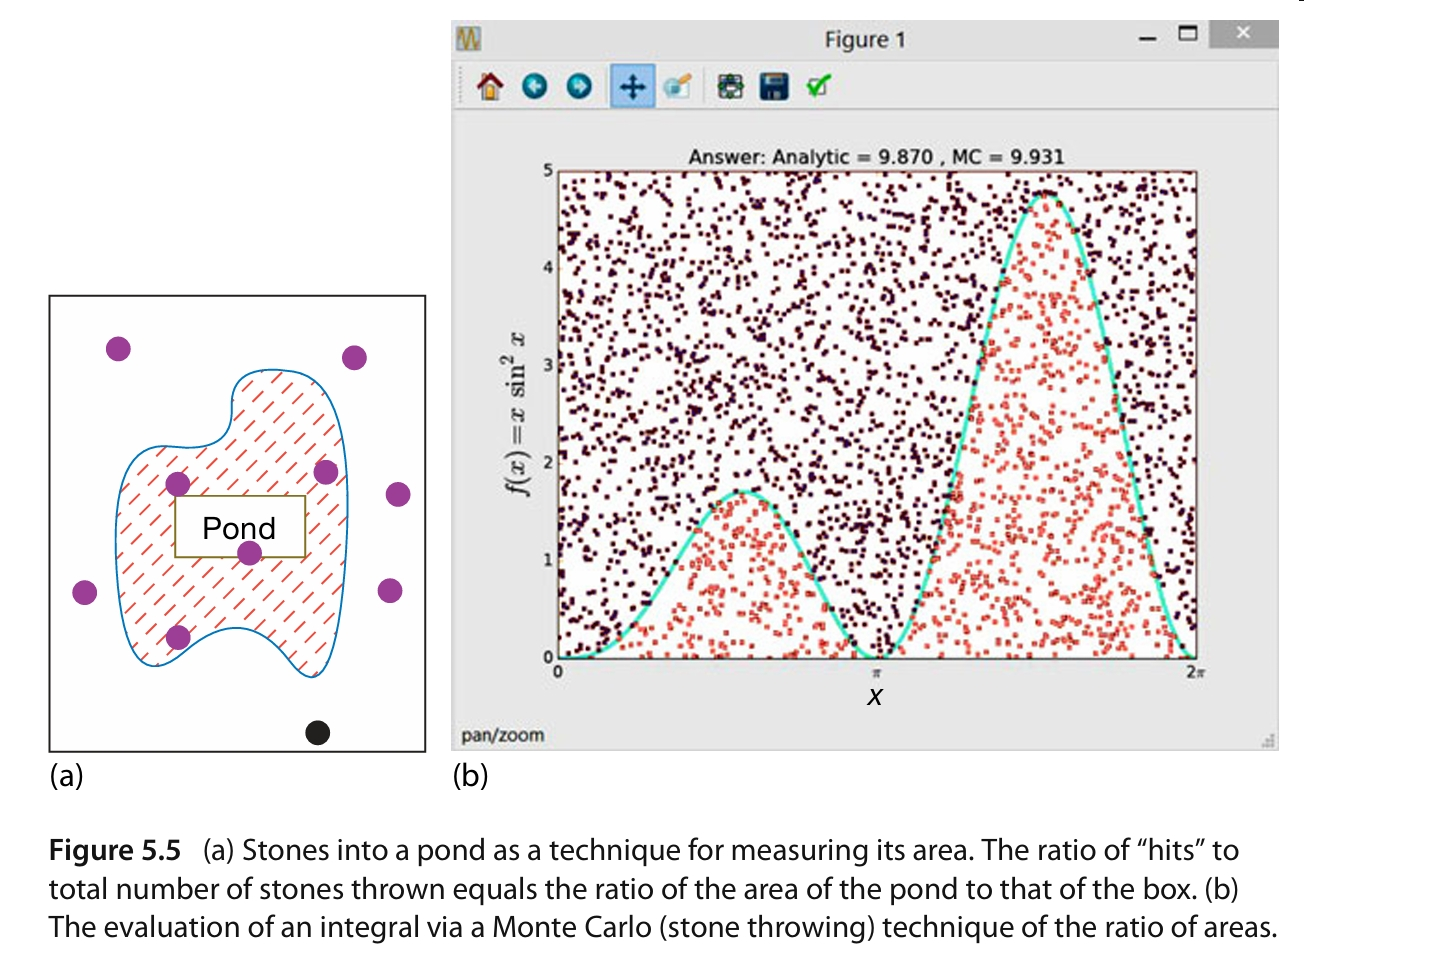

#### 5.14.1: Stone Throwing Implementation

Use sampling (Figure 5.5) to perform a 2D integration and thereby determine $\pi$:

1. Imagine a circular pond enclosed in a square of side $2(r = 1)$.

2. We know the analytic answer that the area of a circle $\int dA = \pi$.

3. Generate a sequence of random numbers $-1 \leq r_i \leq +1$.

4. For $i = 1$ to $N$, pick $(x_i, y_i) = (r_{2i-1}, r_{2i})$.

5. If $x_i^2 + y_i^2 < 1$, let $N_{\text{pond}} = N_{\text{pond}} + 1$; otherwise let $N_{\text{box}} = N_{\text{box}} + 1$.

6. Use (5.76) to calculate the area, and in this way $\pi$.

7. Increase $N$ until you get $\pi$ to three significant figures, we do not ask much -- that is only slide-rule accuracy.

In [ ]:
side = 2 ; radius = 1
AreaBox = side ** 2

In [ ]:
Trm = 2**64 ; Tra = 6364136223846793005 ; Trc = 1442695040888963407 ; Trr1 = 123456789123456789

# range: [0, (2**64) - 1]

N = 1000

TrLCGrandseq = [Trr1]
for i in range(0, 2 * N):
    TrLCGrandseq.append((((TrLCGrandseq[i] * Tra) + Trc) % Trm))

TrLCGrandseq = np.array(TrLCGrandseq)
integRandseq = TrLCGrandseq / (2**64)
integRandseq = (-1) + (1 - (-1)) * integRandseq

# plt.plot(integRandseq)
print("hello world")

Npond = 0
Nbox = 0
for i in range(0, N):
    x = integRandseq[2*i] ; y = integRandseq[2*i + 1]
    if x**2 + y**2 < 1 :
        Npond += 1
    else:
        Nbox += 1

print(Npond, Nbox)
AreaFraction = Npond / (Npond + Nbox)
MAreaPond = AreaFraction * AreaBox
print(MAreaPond)

hello world
772 228
3.088


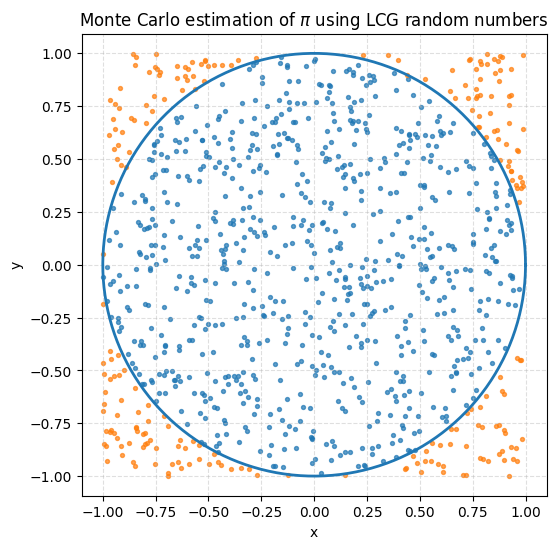

In [ ]:
x = integRandseq[0 : 2*N : 2]
y = integRandseq[1 : 2*N : 2]

inside = x**2 + y**2 < 1

plt.figure(figsize=(6, 6))

plt.scatter(x[inside], y[inside], s=8, alpha=0.7, label="Inside pond")
plt.scatter(x[~inside], y[~inside], s=8, alpha=0.7, label="Outside pond")

theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="True circle")

plt.axis("equal")
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Monte Carlo estimation of $\pi$ using LCG random numbers")
plt.show()

## Multidimensional Integral Example: Maxwell-Boltzmann Momentum Integral

In the canonical ensemble, the momentum part of the single-particle partition function is

$$
I =
\int_{-\infty}^{+\infty}
\int_{-\infty}^{+\infty}
\int_{-\infty}^{+\infty}
e^{-\beta(p_x^2+p_y^2+p_z^2)/(2m)}
\,dp_x\,dp_y\,dp_z.
$$

This integral appears in the classical ideal gas partition function.

For one particle,

$$
Z_1 =
\frac{V}{h^3}
\int e^{-\beta p^2/(2m)}\,d^3p.
$$

Here,

$$
p^2 = p_x^2+p_y^2+p_z^2.
$$

The exact analytical result is

$$
I_{\mathrm{exact}}
=
\left(\frac{2\pi m}{\beta}\right)^{3/2}.
$$

For simplicity, we choose

$$
m=1,\qquad \beta=1.
$$

Therefore,

$$
I_{\mathrm{exact}} = (2\pi)^{3/2}.
$$

Since numerical methods cannot directly integrate from $-\infty$ to $+\infty$, we approximate the domain by a finite cube:

$$
-L \le p_x,p_y,p_z \le L.
$$

For large enough $L$, the missing tail contribution is very small because the integrand decays exponentially.

In [ ]:
from math import erf
beta = 1 ; m = 1

L = 5.0
Volume = (2*L)**3
N = 1000

def integrand(px, py, pz):
    return np.exp((-beta / (2*m)) * (px**2 + py**2 + pz**2))

Trm = 2**64 ; Tra = 6364136223846793005 ; Trc = 1442695040888963407 ; Trr1 = 123456789123456789

# range: [0, (2**64) - 1]

TrLCGrandseq = [Trr1]
for i in range(0, 3 * N):
    TrLCGrandseq.append((((TrLCGrandseq[i] * Tra) + Trc) % Trm))

TrLCGrandseq = np.array(TrLCGrandseq)
integRandseq = TrLCGrandseq / (2**64)
integRandseq = -5 + (10) * integRandseq

px = [] ; py = [] ; pz = []
for i in range(0, N):
    px.append(integRandseq[3*i])
    py.append(integRandseq[3*i +1])
    pz.append(integRandseq[3*i + 2])
px = np.array(px) ; py = np.array(py) ; pz = np.array(pz)

fvalues = integrand(px, py, pz)

I_MC = Volume * np.mean(fvalues)
print("The result of MonteCarlo Integration: " , I_MC )

# error
Sigma_MC = Volume * np.std(fvalues, ddof=1) / np.sqrt(N)
print("Monte Carlo uncertainty =", Sigma_MC)

I_exact_infinite = (2*np.pi*m/beta)**(3/2)
print("Exact value over infinite domain =", I_exact_infinite)

print("Relative error (%) =", abs(I_MC - I_exact_infinite) / I_exact_infinite * 100)

The result of MonteCarlo Integration:  13.70414952957696
Monte Carlo uncertainty = 2.0629790414060647
Exact value over infinite domain = 15.749609945722419
Relative error (%) = 12.987371898064085


#### note: Mean Value integration method

Suppose we want to calculate a multidimensional integral over a volume $V$:

$$
I = \int_V f(x,y,z)\,dV.
$$

The average value of the function over this volume is defined as

$$
\langle f \rangle =
\frac{1}{V}
\int_V f(x,y,z)\,dV.
$$

Now we rearrange this equation:

$$
\int_V f(x,y,z)\,dV
=
V\langle f\rangle.
$$

Therefore, the integral can be interpreted as

$$
I =
V \times \text{average height of the function}.
$$


## Error Analysis of the Monte Carlo Pond-Area Method

In this simulation, we estimate the area of the pond by throwing random points inside a square box.

The square is

$$
[-1,1]\times[-1,1],
$$

so its area is

$$
A_{\mathrm{box}} = 4.
$$

The pond is a unit circle, so its exact area is

$$
A_{\mathrm{pond}} = \pi.
$$

The Monte Carlo estimate is based on the fraction of random points that fall inside the circle:

$$
\frac{A_{\mathrm{pond}}}{A_{\mathrm{box}}}
\approx
\frac{N_{\mathrm{pond}}}{N}.
$$

Therefore,

$$
A_{\mathrm{pond}} \approx A_{\mathrm{box}}\frac{N_{\mathrm{pond}}}{N}.
$$

Since $A_{\mathrm{box}}=4$, the estimate becomes

$$
\pi_{\mathrm{MC}} = 4\frac{N_{\mathrm{pond}}}{N}.
$$

---

### Binomial Interpretation

Each random point has only two possible outcomes:

$$
\text{inside circle} \quad \text{or} \quad \text{outside circle}.
$$

So each point is a binary trial. We call landing inside the circle a "success".

If the probability that one point lands inside the circle is $p$, then the number of successful points follows a binomial distribution:

$$
N_{\mathrm{pond}} \sim \mathrm{Binomial}(N,p).
$$

This means that the probability of getting exactly $k$ points inside the circle is

$$
P(N_{\mathrm{pond}}=k)
=
\binom{N}{k}p^k(1-p)^{N-k}.
$$

For our unit circle inside the square,

$$
p = \frac{A_{\mathrm{pond}}}{A_{\mathrm{box}}}
=
\frac{\pi}{4}.
$$

So the expected number of points inside the circle is

$$
\langle N_{\mathrm{pond}} \rangle = Np.
$$

The variance of a binomial random variable is

$$
\mathrm{Var}(N_{\mathrm{pond}})=Np(1-p).
$$

Therefore, the standard deviation is

$$
\sigma_{N_{\mathrm{pond}}}
=
\sqrt{Np(1-p)}.
$$

---

### Error of the Fraction

The Monte Carlo method uses the fraction

$$
\frac{N_{\mathrm{pond}}}{N}.
$$

So we need the uncertainty of this fraction.

Because

$$
\mathrm{Var}(aX)=a^2\mathrm{Var}(X),
$$

we get

$$
\mathrm{Var}\left(\frac{N_{\mathrm{pond}}}{N}\right)
=
\frac{1}{N^2}\mathrm{Var}(N_{\mathrm{pond}}).
$$

Using

$$
\mathrm{Var}(N_{\mathrm{pond}})=Np(1-p),
$$

we get

$$
\mathrm{Var}\left(\frac{N_{\mathrm{pond}}}{N}\right)
=
\frac{Np(1-p)}{N^2}.
$$

So

$$
\mathrm{Var}\left(\frac{N_{\mathrm{pond}}}{N}\right)
=
\frac{p(1-p)}{N}.
$$

Therefore, the standard error of the fraction is

$$
\sigma_p
=
\sqrt{\frac{p(1-p)}{N}}.
$$

---

### Error of the Monte Carlo Area

The estimated area is

$$
A_{\mathrm{MC}}
=
A_{\mathrm{box}}\frac{N_{\mathrm{pond}}}{N}.
$$

So its uncertainty is

$$
\sigma_A
=
A_{\mathrm{box}}\sqrt{\frac{p(1-p)}{N}}.
$$

Since $A_{\mathrm{box}}=4$,

$$
\sigma_{\pi}
=
4\sqrt{\frac{p(1-p)}{N}}.
$$

In practice, we usually estimate $p$ from the simulation itself:

$$
p \approx \hat{p} = \frac{N_{\mathrm{pond}}}{N}.
$$

So the estimated uncertainty becomes

$$
\sigma_{\pi}
\approx
4\sqrt{\frac{\hat{p}(1-\hat{p})}{N}}.
$$

---

### Main Monte Carlo Error Relation

The important part is that

$$
\sigma_{\pi}
\propto
\frac{1}{\sqrt{N}}.
$$

So the Monte Carlo error decreases like

$$
\boxed{
\text{Monte Carlo error} \sim \frac{1}{\sqrt{N}}
}
$$

This is a slow convergence rate. To make the error 10 times smaller, we need about 100 times more random points.

---

### Absolute and Relative Error

After computing the estimate, we can compare it with the exact value $\pi$.

The absolute error is

$$
E_{\mathrm{abs}}
=
|\pi_{\mathrm{MC}}-\pi|.
$$

The relative error is

$$
E_{\mathrm{rel}}
=
\frac{|\pi_{\mathrm{MC}}-\pi|}{\pi}.
$$

The percentage relative error is

$$
E_{\mathrm{rel}}(\%)
=
100\times
\frac{|\pi_{\mathrm{MC}}-\pi|}{\pi}.
$$

---

### Key Takeaway

The Monte Carlo method does not give an exact answer from one run. It gives a statistical estimate.

The randomness creates fluctuations in $N_{\mathrm{pond}}$, and these fluctuations create error in the estimate of $\pi$.

Because the number of inside points follows a binomial distribution, the statistical uncertainty decreases as

$$
\frac{1}{\sqrt{N}}.
$$